In [1]:
# Imports
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
import numpy as np
import random
import json

In [2]:
# Loading Data
data = pd.read_parquet("../data/pitching_data.parquet")

In [3]:
poi_metrics = pd.read_csv("../data/poi_metrics.csv")
poi_metrics = poi_metrics[["session_pitch", "session", "p_throws", "pitch_speed_mph"]]
poi_metrics["session_key"] = poi_metrics['session'].astype(str)
poi_metrics_unique = poi_metrics[["session_key", "p_throws"]].drop_duplicates()

In [4]:
data["session_key"] = (data["sessionID"].astype(str).str.lstrip("0"))

In [5]:
data = data.merge(
    poi_metrics_unique,
    on = "session_key",
    how = "left"
)
data.head(2)

,userID,sessionID,height,weight,pitchNum,pitchType,pitchSpeed,frame,markerID,x,y,z,residual,session_key,p_throws
0,000002,003034,73,207,002,FF,80.9,0,0,0.003564,-0.068032,1.581415,1.0,3034,R
1,000002,003034,73,207,002,FF,80.9,0,1,0.057339,-0.186507,1.495219,1.0,3034,R


In [6]:
data.loc[data['p_throws'] == 'L', 'y'] *= -1
data.head(2)

,userID,sessionID,height,weight,pitchNum,pitchType,pitchSpeed,frame,markerID,x,y,z,residual,session_key,p_throws
0,000002,003034,73,207,002,FF,80.9,0,0,0.003564,-0.068032,1.581415,1.0,3034,R
1,000002,003034,73,207,002,FF,80.9,0,1,0.057339,-0.186507,1.495219,1.0,3034,R


In [7]:
# Getting pivot table

pivot_df = data.pivot(
    index = ["userID", "sessionID", "pitchNum", "height", "weight", "frame", "pitchType", "pitchSpeed"],
    columns = "markerID",
    values = ["x", "y", "z"]
)
pivot_df.columns = [f"{coord}_marker{marker}" for coord, marker in pivot_df.columns]
pivot_df = pivot_df.dropna()
pivot_df.head(2)

x_marker0  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.081724   
                                        1     FF        93.1         0.081674   

                                                                    x_marker1  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.154192   
                                        1     FF        93.1         0.153949   

                                                                    x_marker2  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.269110   
                                        1     FF        93.1         0.269096   

                                                                    x_marker3  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.302442   
                                        1     FF        93.1         0.302310   

                                                                    x_marker4  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.150238   
                                        1     FF        93.1         0.150415   

                                                                    x_marker5  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.094892   
                                        1     FF        93.1         0.094827   

                                                                    x_marker6  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.430795   
                                        1     FF        93.1         0.431003   

                                                                    x_marker7  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.204421   
                                        1     FF        93.1         0.204310   

                                                                    x_marker8  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.330168   
                                        1     FF        93.1         0.329869   

                                                                    x_marker9  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed              
000511 001688    003      78     235    0     FF        93.1         0.391722   
                                        1     FF        93.1         0.391775   

                                                                    ...  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed  ...   
000511 001688    003      78     235    0     FF        93.1        ...   
                                        1     FF        93.1        ...   

                                                                    z_marker38  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed               
000511 001688    003      78     235    0     FF        93.1          1.164060   
                                        1     FF        93.1          1.164092   

                                                                    z_marker39  \
userID sessionID pitchNum height weight frame pitchType pitchSpeed               
000511 001688    003    

In [8]:
# Identify y-coordinate columns
y_cols = [c for c in pivot_df.columns if c.startswith("y_marker")]

# Keys that define a single pitch
group_keys = ["userID", "sessionID", "pitchNum"]

# Subtract the first-frame mean Y (across all markers) from every frame of that pitch
pivot_df_centered = pivot_df.copy()

# Compute each pitch's first-frame mean Y
first_frame_mean_y = (
    pivot_df_centered
    .groupby(group_keys)[y_cols]
    .transform(lambda g: g.iloc[0].mean())  # scalar baseline per pitch
)

# Subtract that baseline so each pitch starts at mean(y)=0
pivot_df_centered[y_cols] = pivot_df_centered[y_cols] - first_frame_mean_y

In [9]:
# Doing PCA with 3 components
X = pivot_df_centered.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components = 3)

# Reconstructing data from PCA
scores = pca.fit_transform(X_scaled)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_))

Cumulative explained variance: [49.71127942 66.3642254  77.77973113]


In [10]:
# Making dataframe to hold reconstruction data
scores_df = pivot_df_centered.copy().reset_index()

for i in range(scores.shape[1]):
    scores_df[f"PC{i+1}"] = scores[:, i]

# Drop marker columns for clarity
feature_cols = [col for col in scores_df.columns if col.startswith(('x_', 'y_', 'z_'))]
scores_df = scores_df.drop(columns=feature_cols)

scores_df.head(2)

,userID,sessionID,pitchNum,height,weight,frame,pitchType,pitchSpeed,PC1,PC2,PC3
0,000511,001688,003,78,235,0,FF,93.1,-6.233424,-2.627171,1.966257
1,000511,001688,003,78,235,1,FF,93.1,-6.234039,-2.627109,1.962191


In [11]:
# Number of frames wanted
N_TARGET_FRAMES = 101

# Normalizing data to be viewed as 0-100% of motion
def normalize_pitch_frames(group):
    frame_norm = np.linspace(0, 100, N_TARGET_FRAMES) # Values
    normalized_data = {"frame_norm": frame_norm}

    for pc in ["PC1", "PC2", "PC3"]:
        normalized_data[pc] = resample(group[pc].values, N_TARGET_FRAMES)

    # Add metadata
    for col in ["userID", "sessionID", "pitchNum", "height", "weight", "pitchType", "pitchSpeed"]:
        normalized_data[col] = group[col].iloc[0]

    return pd.DataFrame(normalized_data)

# Get normalized dataframe
normalized_df = (
    scores_df
    .groupby(["userID", "sessionID", "pitchNum", "height", "weight", "pitchType", "pitchSpeed"], group_keys=False)
    .apply(normalize_pitch_frames)
)

normalized_df.head(2)

/tmp/ipykernel_29011/605548131.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(normalize_pitch_frames)


,frame_norm,PC1,PC2,PC3,userID,sessionID,pitchNum,height,weight,pitchType,pitchSpeed
0,0.0,2.119931,-3.263697,1.992651,000511,001688,003,78,235,FF,93.1
1,1.0,-7.960628,-2.494927,1.922557,000511,001688,003,78,235,FF,93.1


In [12]:
pcs = ["PC1", "PC2", "PC3"]
mean_df = normalized_df.groupby("frame_norm")[["PC1", "PC2", "PC3"]].mean().reset_index()
mean_df = mean_df.rename(columns = {'PC1' : 'PC1_mean', 'PC2' : 'PC2_mean', 'PC3' : 'PC3_mean'})

# Merge mean with normalized
merged = normalized_df.merge(mean_df, on="frame_norm", how="left")

for pc in pcs:
    merged[f"{pc}_diff"] = merged[pc] - merged[f"{pc}_mean"]

In [13]:
# Select six pitches (max and min per PC)
# Produces `pitch_of_interest` as a list of (userID, sessionID, pitchNum)
agg = (
    merged
    .groupby(["userID", "sessionID", "pitchNum"], as_index=False)
    .agg(
        PC1_max=("PC1_diff", "max"),
        PC1_min=("PC1_diff", "min"),
        PC2_max=("PC2_diff", "max"),
        PC2_min=("PC2_diff", "min"),
        PC3_max=("PC3_diff", "max"),
        PC3_min=("PC3_diff", "min"),
        # optional: largest absolute deviation per pitch
        PC1_maxabs=("PC1_diff", lambda x: x.abs().max()),
        PC2_maxabs=("PC2_diff", lambda x: x.abs().max()),
        PC3_maxabs=("PC3_diff", lambda x: x.abs().max()),
    )
)

# For each PC pick the pitch with the largest positive peak and the pitch with the most negative trough
selected = []
for pc in [1, 2, 3]:
    max_col = f"PC{pc}_max"
    min_col = f"PC{pc}_min"
    # idxmax/idxmin will raise if column is all-NaN; guard with try/except
    try:
        max_row = agg.loc[agg[max_col].idxmax()]
        selected.append((max_row["userID"], max_row["sessionID"], max_row["pitchNum"]))
    except Exception:
        pass
    try:
        min_row = agg.loc[agg[min_col].idxmin()]
        selected.append((min_row["userID"], min_row["sessionID"], min_row["pitchNum"]))
    except Exception:
        pass

# Remove duplicates while preserving order (in case same pitch wins multiple slots)
seen = set()
pitch_of_interest = []
for t in selected:
    if t not in seen:
        seen.add(t)
        pitch_of_interest.append(t)

print("Selected pitches (userID, sessionID, pitchNum):")
for p in pitch_of_interest:
    print(p)

Selected pitches (userID, sessionID, pitchNum):
('000967', '001620', '002')
('001003', '001729', '002')
('000906', '001371', '003')
('000967', '001620', '010')
('000952', '001574', '006')


In [14]:
poi_records = []

# Keep track of which PC/max/min selected each pitch
for pc in [1,2,3]:
    for extreme in ["max", "min"]:
        col = f"PC{pc}_{extreme}"
        try:
            row = agg.loc[agg[col].idxmax() if extreme=="max" else agg[col].idxmin()]
            poi = (row["userID"], row["sessionID"], row["pitchNum"])
            desc = f"PC{pc} {extreme}"
            # check if POI already added
            existing = next((r for r in poi_records if r["pitch_of_interest"] == poi), None)
            if existing:
                existing["description"] += f", {desc}"
            else:
                poi_records.append({"POI #": len(poi_records)+1, "pitch_of_interest": poi, "description": desc})
        except Exception:
            continue

poi_df = pd.DataFrame(poi_records)
display(poi_df)

,POI #,pitch_of_interest,description
0,1,"(000967, 001620, 002)","PC1 max, PC2 min"
1,2,"(001003, 001729, 002)",PC1 min
2,3,"(000906, 001371, 003)",PC2 max
3,4,"(000967, 001620, 010)",PC3 max
4,5,"(000952, 001574, 006)",PC3 min


In [15]:
# Build a mapping: POI -> list of PCs where it is min/max
poi_to_pcs = {}
for idx, r in enumerate(poi_records):
    # extract PC numbers from description like "PC1 max, PC3 min"
    pcs_for_poi = [d.split()[0] for d in r["description"].split(", ")]
    poi_to_pcs[r["pitch_of_interest"]] = pcs_for_poi

# Assign a color to each POI
poi_colors = cm.tab10.colors[:len(pitch_of_interest)]  # or any colormap
poi_to_color = {poi: poi_colors[i] for i, poi in enumerate(pitch_of_interest)}

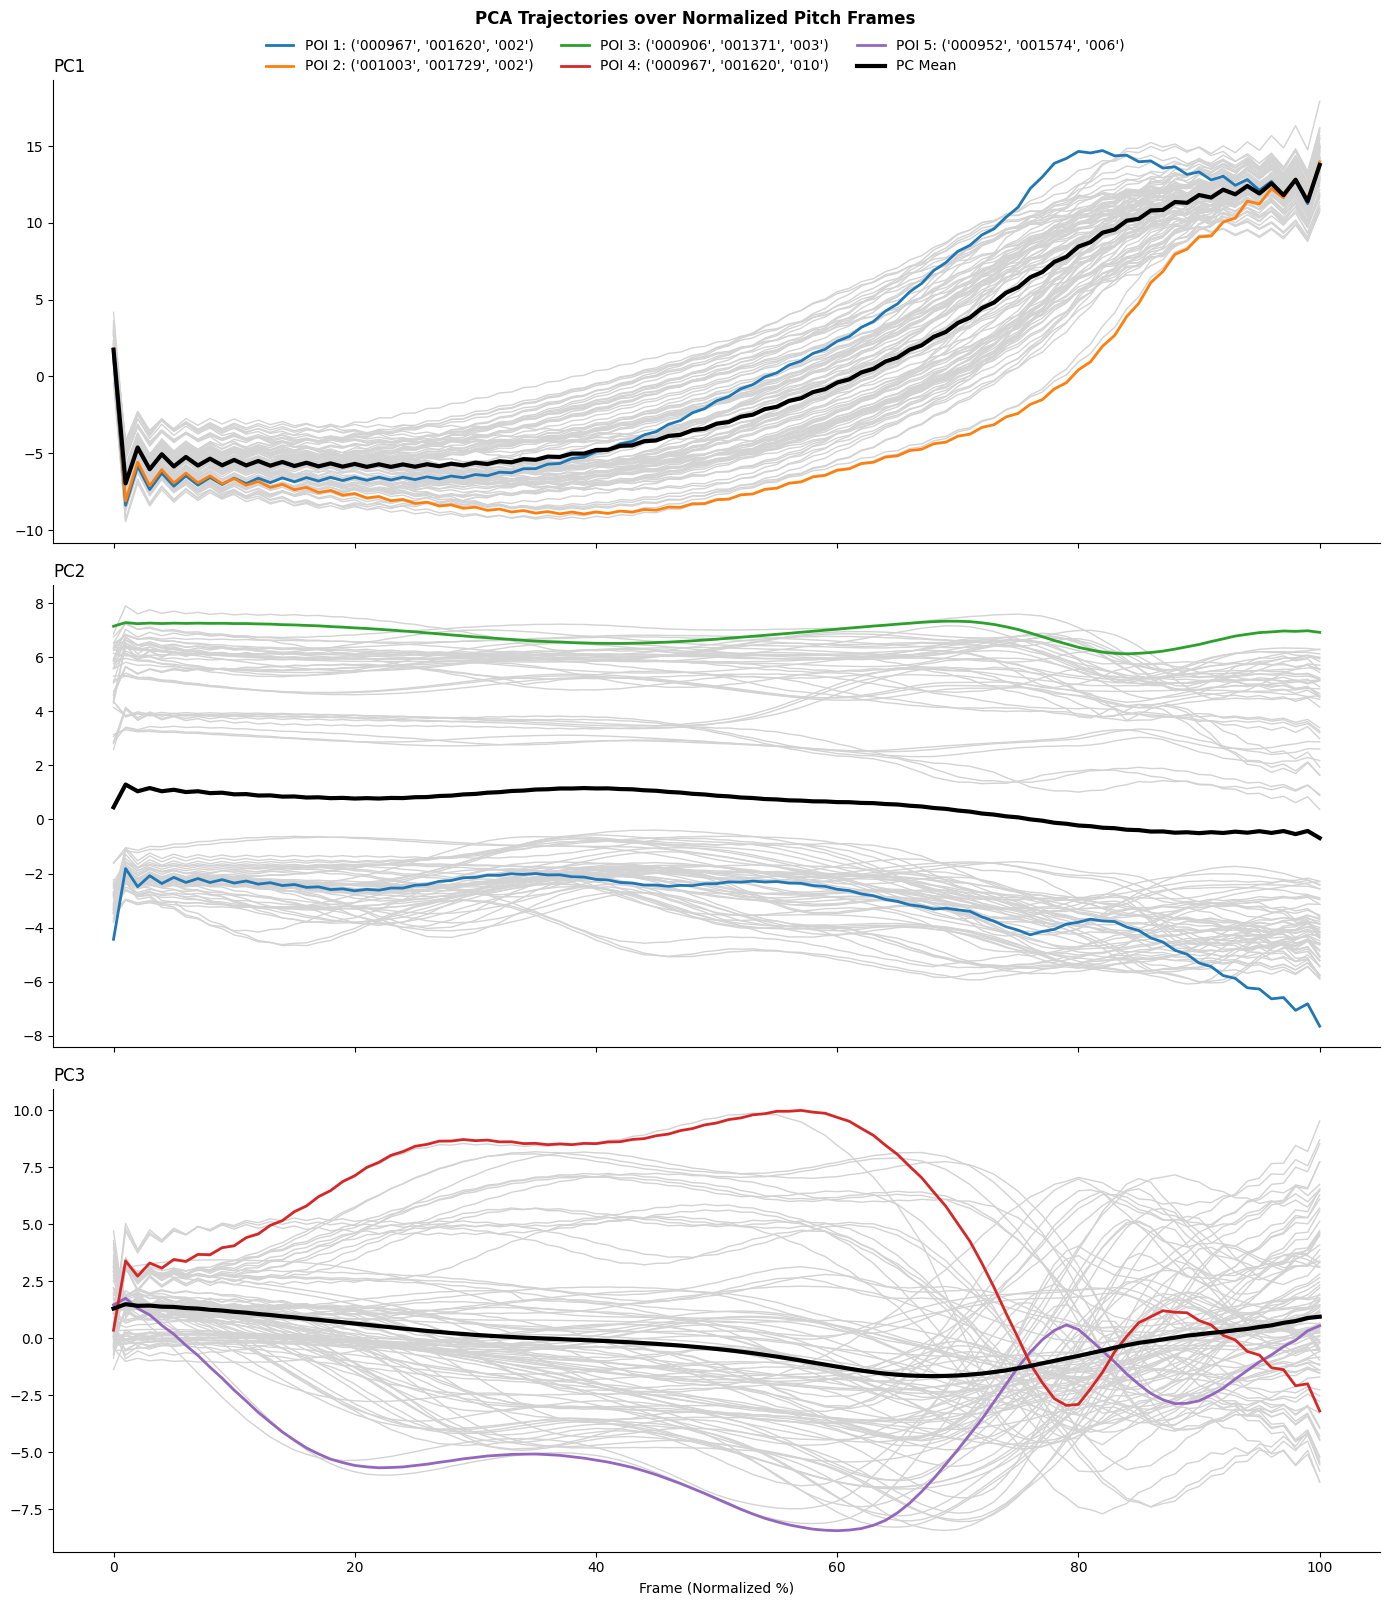

In [16]:
# Initialize subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 16), sharex=True)

for i, pc in enumerate(pcs):
    ax = axes[i]

    # Grand mean line
    mean_pc = normalized_df.groupby("frame_norm")[pc].mean()
    ax.plot(mean_pc.index, mean_pc.values, color="black", linewidth=3, label="PC Mean", zorder=3)

    # Loop over each pitch
    for (sess, uid, pid, height, weight, pitchType, pitchSpeed), grp in normalized_df.groupby(
        ["sessionID", "userID", "pitchNum", "height", "weight", "pitchType", "pitchSpeed"], sort=False):

        key = (uid, sess, pid)
        # Only color if this POI is min/max for current PC
        if key in poi_to_color and pc in poi_to_pcs[key]:
            color = poi_to_color[key]
            lw = 2
            zorder = 2
            label = f"POI {pitch_of_interest.index(key)+1}"  # numbered POIs
        else:
            color = "lightgray"
            lw = 1
            zorder = 1
            label = ''

        ax.plot(grp["frame_norm"], grp[pc], color=color, linewidth=lw, zorder=zorder, label=label)

    ax.set_title(f"{pc}", loc="left")
    sns.despine(ax=ax, top=True, right=True)

# Create a single figure-level legend
handles, labels = [], []
for poi in pitch_of_interest:
    handles.append(ax.plot([], [], color=poi_to_color[poi], lw=2)[0])
    labels.append(f"POI {pitch_of_interest.index(poi)+1}: {poi}")
handles.append(ax.plot([], [], color="black", lw=3)[0])
labels.append("PC Mean")

fig.legend(handles, labels, loc="upper center", frameon=False, ncol=3,
           bbox_to_anchor=(0.5, 0.99))

axes[-1].set_xlabel("Frame (Normalized %)")
fig.suptitle("PCA Trajectories over Normalized Pitch Frames", ha="center", weight='bold', y = 1)
plt.tight_layout()
plt.savefig("./plots/pca_plot.png")
plt.show()


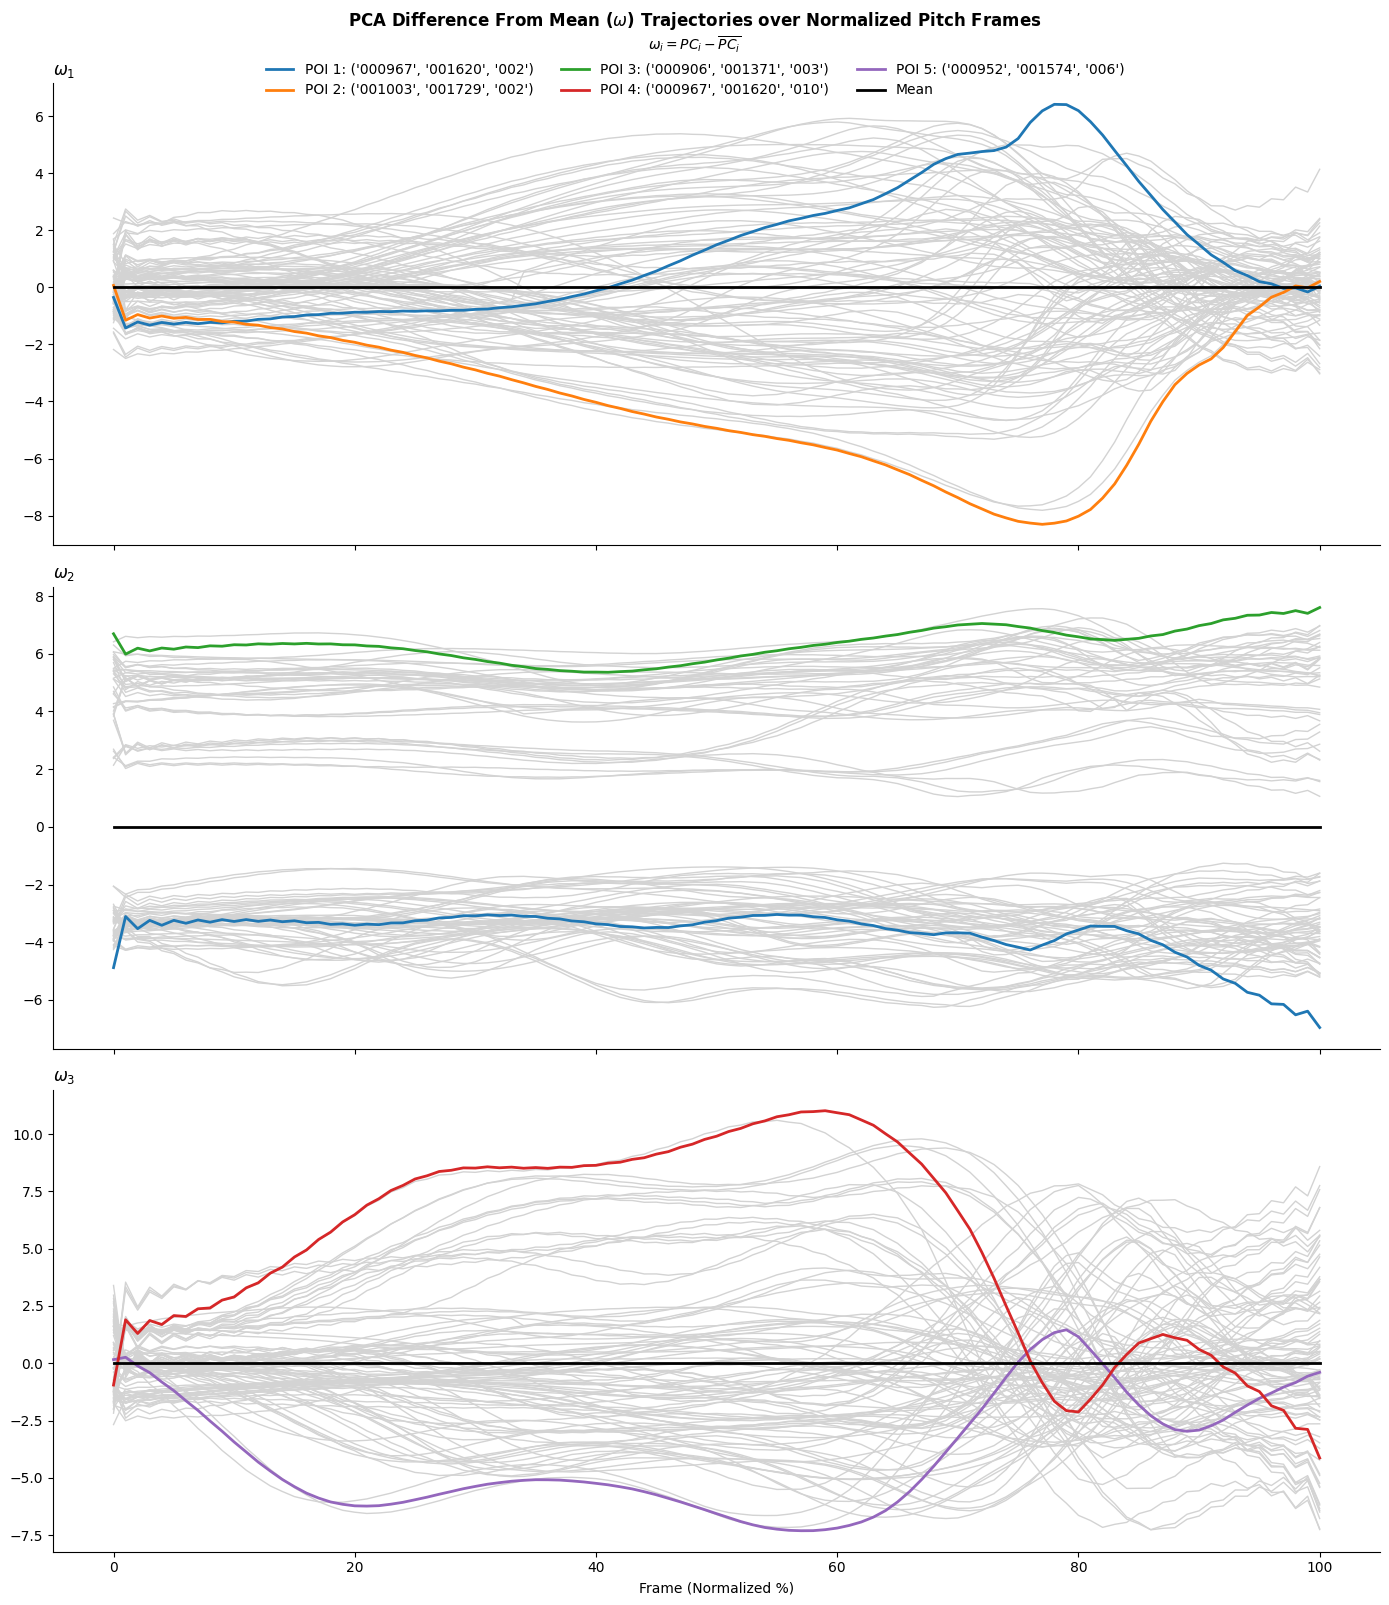

In [17]:
deltas = [r"$\omega_1$", r"$\omega_2$", r"$\omega_3$"]
pca_to_delta = dict(zip(pcs, deltas))

# --- Initialize subplots ---
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14,16), sharex=True)

for i, pc in enumerate(pcs):
    ax = axes[i]

    # Grand mean line
    mean_pc = merged.groupby("frame_norm")[f"{pc}_diff"].mean()
    ax.plot(mean_pc.index, mean_pc.values, color="black", linewidth=2, label="Mean", zorder=3)

    # Loop over each pitch
    for (sess, uid, pid, height, weight, pitchType, pitchSpeed), grp in merged.groupby(
        ["sessionID","userID","pitchNum","height","weight","pitchType","pitchSpeed"], sort=False):

        key = (uid, sess, pid)
        # Only color if this POI is min/max for current PC
        if key in poi_to_color and pc in poi_to_pcs[key]:
            color = poi_to_color[key]
            lw = 2
            zorder = 2
            label = f"POI {poi_records.index(next(r for r in poi_records if r['pitch_of_interest']==key))+1}"
        else:
            color = "lightgray"
            lw = 1
            zorder = 1
            label = ''

        ax.plot(grp["frame_norm"], grp[f"{pc}_diff"], color=color, linewidth=lw, zorder=zorder, label=label)

    ax.set_title(f"{pca_to_delta[pc]}", loc="left")
    sns.despine(ax=ax, top=True, right=True)

# --- Figure-level legend ---
handles, labels = [], []
for r in poi_records:
    poi = r["pitch_of_interest"]
    handles.append(ax.plot([], [], color=poi_to_color[poi], lw=2)[0])
    labels.append(f"POI {r['POI #']}: {poi}")
handles.append(ax.plot([], [], color="black", lw=2)[0])
labels.append("Mean")

fig.legend(handles, labels, loc="upper center", frameon=False, ncol=3, bbox_to_anchor=(0.5,0.975))

axes[-1].set_xlabel("Frame (Normalized %)")
fig.suptitle(f"PCA Difference From Mean ($\omega$) Trajectories over Normalized Pitch Frames", 
             ha="center", weight='bold', y=1.0)
fig.text(0.5, 0.975, r"$\omega_i = PC_i - \overline{PC_i}$", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("./plots/diff_plot.png")
plt.show()


In [18]:
def singleview(pitch_number):
    with open("../data/pitch_marker_mapping.json", 'r') as f:
        pitch_marker_mapping = json.load(f)


    # Pitch selection
    # pitch_number = 0
    userID = pitch_of_interest[pitch_number][0]
    sessionID = pitch_of_interest[pitch_number][1]
    pitchNum = pitch_of_interest[pitch_number][2]

    sel = data[
        (data['userID'] == userID) &
        (data['sessionID'] == sessionID) &
        (data['pitchNum'] == pitchNum)
    ].copy()
    sel = sel.sort_values('frame')

    # Step 1: identify first frame
    first_frame = sel['frame'].min()

    # Step 2: compute first-frame mean Y (only valid markers)
    first_frame_mean_y = sel[sel['frame'] == first_frame]['y'].mean()

    # Step 3: subtract baseline from all frames
    sel['y'] = sel['y'] - first_frame_mean_y

    # Step 4: verify
    print("First-frame mean Y after centering:", sel[sel['frame'] == first_frame]['y'].mean())


    # --- Load C3D file for marker labels ---
    height = sel['height'].iloc[0]
    weight = sel['weight'].iloc[0]
    pitchType = sel['pitchType'].iloc[0]
    pitchSpeed = str(int(sel['pitchSpeed'].iloc[0]*10))
    hand = sel["p_throws"].iloc[0]


    pitch_key = f"{userID}_{sessionID}_{pitchNum}"
    marker_labels = pitch_marker_mapping[pitch_key]
    label_to_index = {label: i for i, label in enumerate(marker_labels)}

    # This dictionary helps look up the index for a given label
    def get_idx(label):
        return label_to_index.get(label)


    # Convert dataframe to points array for animation
    # points shape should be (3, num_markers, num_frames)
    unique_markers = sorted(sel['markerID'].unique())
    unique_frames = sorted(sel['frame'].unique())
    num_markers = len(unique_markers)
    num_frames = len(unique_frames)

    marker_to_idx = {marker: i for i, marker in enumerate(unique_markers)}
    frame_to_idx = {frame: i for i, frame in enumerate(unique_frames)}

    points = np.full((3, num_markers, num_frames), np.nan)
    for _, row in sel.iterrows():
        m_idx = marker_to_idx[row['markerID']]
        f_idx = frame_to_idx[row['frame']]
        points[0, m_idx, f_idx] = row['x']
        points[1, m_idx, f_idx] = row['y']
        points[2, m_idx, f_idx] = row['z']

    # Define connections
    skeleton_connections_labels = [
        # Head and Neck
        (get_idx('LBHD'), get_idx('LFHD')), # Left Head
        (get_idx('RBHD'), get_idx('RFHD')), # Right Head
        (get_idx('LFHD'), get_idx('RFHD')), # Forehead
        (get_idx('LBHD'), get_idx('RBHD')), # Back of Head
        (get_idx('C7'), get_idx('STRN')),  # Neck to Sternum (approx. upper torso center)
        (get_idx('C7'), get_idx('CLAV')),  # C7 to Clavicle (upper spine to shoulder girdle)
        
        # Torso
        (get_idx('STRN'), get_idx('CLAV')), # Sternum to Clavicle
        (get_idx('CLAV'), get_idx('LSHO')), # Clavicle to Left Shoulder
        (get_idx('CLAV'), get_idx('RSHO')), # Clavicle to Right Shoulder
        (get_idx('LSHO'), get_idx('RSHO')), # Across shoulders
        (get_idx('LSHO'), get_idx('LASI')), # Left Shoulder to Left ASIS (approx. body side)
        (get_idx('RSHO'), get_idx('RASI')), # Right Shoulder to Right ASIS
        (get_idx('LASI'), get_idx('RASI')), # Across hips
        (get_idx('LPSI'), get_idx('RPSI')), # Across posterior hips (if available, good for pelvis)
        (get_idx('LASI'), get_idx('LPSI')), # Left ASIS to Left PSIS
        (get_idx('RASI'), get_idx('RPSI')), # Right ASIS to Right PSIS
        
        # Left Arm
        (get_idx('LSHO'), get_idx('LUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('LUPA'), get_idx('LELB')), # Upper Arm to Elbow
        (get_idx('LELB'), get_idx('LFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('LFRM'), get_idx('LWRA')), # Forearm to Wrist A
        (get_idx('LWRA'), get_idx('LWRB')), # Wrist A to Wrist B
        (get_idx('LWRB'), get_idx('LFIN')), # Wrist B to Finger
        
        # Right Arm
        (get_idx('RSHO'), get_idx('RUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('RUPA'), get_idx('RELB')), # Upper Arm to Elbow
        (get_idx('RELB'), get_idx('RFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('RFRM'), get_idx('RWRA')), # Forearm to Wrist A
        (get_idx('RWRA'), get_idx('RWRB')), # Wrist A to Wrist B
        (get_idx('RWRB'), get_idx('RFIN')), # Wrist B to Finger

        # Left Leg
        (get_idx('LASI'), get_idx('LTHI')), # ASIS to Thigh (femur)
        (get_idx('LTHI'), get_idx('LKNE')), # Thigh to Knee
        (get_idx('LKNE'), get_idx('LTIB')), # Knee to Tibia
        (get_idx('LTIB'), get_idx('LANK')), # Tibia to Ankle
        (get_idx('LANK'), get_idx('LHEE')), # Ankle to Heel
        (get_idx('LANK'), get_idx('LTOE')), # Ankle to Toe
        (get_idx('LHEE'), get_idx('LTOE')), # Heel to Toe
        (get_idx('LANK'), get_idx('LMANK')), # Left Ankle to Medial Ankle (if LMANK is medial)
        
        # Right Leg
        (get_idx('RASI'), get_idx('RTHI')), # ASIS to Thigh (femur)
        (get_idx('RTHI'), get_idx('RKNE')), # Thigh to Knee
        (get_idx('RKNE'), get_idx('RTIB')), # Knee to Tibia
        (get_idx('RTIB'), get_idx('RANK')), # Tibia to Ankle
        (get_idx('RANK'), get_idx('RHEE')), # Ankle to Heel
        (get_idx('RANK'), get_idx('RTOE')), # Ankle to Toe
        (get_idx('RHEE'), get_idx('RTOE')), # Heel to Toe
        (get_idx('RANK'), get_idx('RMANK')) # Right Ankle to Medial Ankle (if RMANK is medial)
    ]

    # Filter out any connections where one or both markers were not found
    skeleton_connections = [conn for conn in skeleton_connections_labels if all(c is not None for c in conn)]

    # Set up plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Set consistent axis limits and viewing angle
    if points.size > 0:
        x_min, x_max = np.nanmin(points[0, :, :]), np.nanmax(points[0, :, :])
        y_min, y_max = np.nanmin(points[1, :, :]), np.nanmax(points[1, :, :])
        z_min, z_max = np.nanmin(points[2, :, :]), np.nanmax(points[2, :, :])
        
        # Add a small buffer to the limits
        buffer = 0.1 * (max(x_max-x_min, y_max-y_min, z_max-z_min) or 1) 
        ax.set_xlim([x_min - buffer, x_max + buffer])
        ax.set_ylim([y_min - buffer, y_max + buffer])
        ax.set_zlim([z_min - buffer, z_max + buffer])
    else:
        # If no data, set some default limits
        ax.set_xlim([-1000, 1000]); ax.set_ylim([-1000, 1000]); ax.set_zlim([0, 2000])

    ax.set_xlabel('X Axis'); ax.set_ylabel('Y Axis'); ax.set_zlabel('Z Axis')
    ax.view_init(elev=30, azim=-55)


    # Initialize scatter plot for the markers
    scatter = ax.scatter(points[0, :, 0], points[1, :, 0], points[2, :, 0], alpha=0.75, color='royalblue', label='Markers')
    title = ax.set_title('Frame 0')

    # Initialize line plots for the skeleton
    lines = []
    for p1_idx, p2_idx in skeleton_connections:
        x = points[0, [p1_idx, p2_idx], 0]
        y = points[1, [p1_idx, p2_idx], 0]
        z = points[2, [p1_idx, p2_idx], 0]
        line, = ax.plot(x, y, z, color='lightcoral', lw=2) 
        lines.append(line)

    # Update function for animation
    def update(frame):


        # Update marker positions
        scatter._offsets3d = (points[0, :, frame], points[1, :, frame], points[2, :, frame])
        title.set_text(f'Handedness: {hand} | Frame: {frame} | Percentage of Motion: {(frame/num_frames) * 100:.1f}%')

        # Update skeleton line positions
        for i, (p1_idx, p2_idx) in enumerate(skeleton_connections):
            x = points[0, [p1_idx, p2_idx], frame]
            y = points[1, [p1_idx, p2_idx], frame]
            z = points[2, [p1_idx, p2_idx], frame]
            
            lines[i].set_data(x, y)
            lines[i].set_3d_properties(z)
        
        # Return all updated artists
        if frame % 50 == 0:
            print(f"On frame {frame} of animation")
        return [scatter, title] + lines

    # Create and save animation
    num_frames = points.shape[2]
    ani = FuncAnimation(fig, update, frames=num_frames, interval=15, blit=False)

    print("Saving animation... please wait.")
    ani.save(f'./animations/singleview/{userID}_{sessionID}_{pitchNum}.mp4', writer ='ffmpeg', fps = 60)
    print(f"Animation saved as {userID}_{sessionID}_{pitchNum}.mp4'")

Starting animation 0
First-frame mean Y after centering: -1.850371707708594e-17
Saving animation... please wait.
On frame 0 of animation
On frame 0 of animation
On frame 50 of animation
On frame 100 of animation
On frame 150 of animation
On frame 200 of animation
On frame 250 of animation
On frame 300 of animation
On frame 350 of animation
On frame 400 of animation
On frame 450 of animation
On frame 500 of animation
On frame 550 of animation
On frame 600 of animation
On frame 650 of animation
On frame 700 of animation
Animation saved as 000967_001620_002.mp4'
Starting animation 1
First-frame mean Y after centering: 0.0
Saving animation... please wait.
On frame 0 of animation
On frame 0 of animation
On frame 50 of animation
On frame 100 of animation
On frame 150 of animation
On frame 200 of animation
On frame 250 of animation
On frame 300 of animation
On frame 350 of animation
On frame 400 of animation
On frame 450 of animation
On frame 500 of animation
On frame 550 of animation
On fram

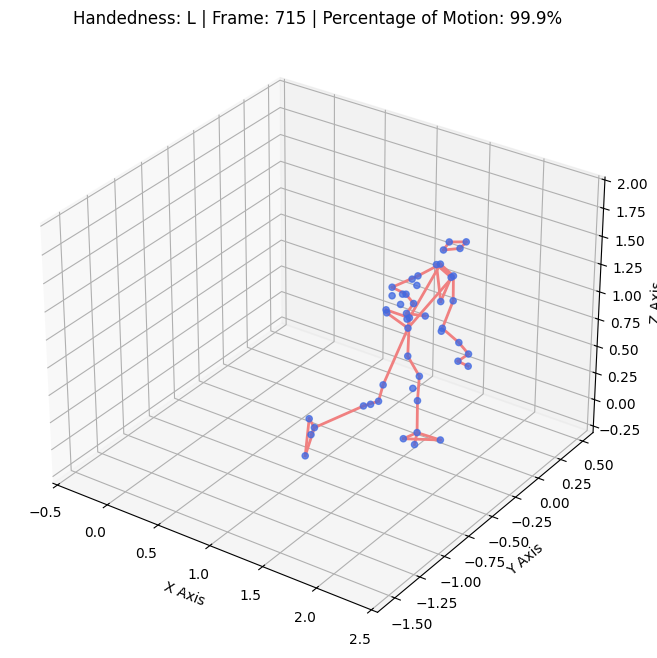

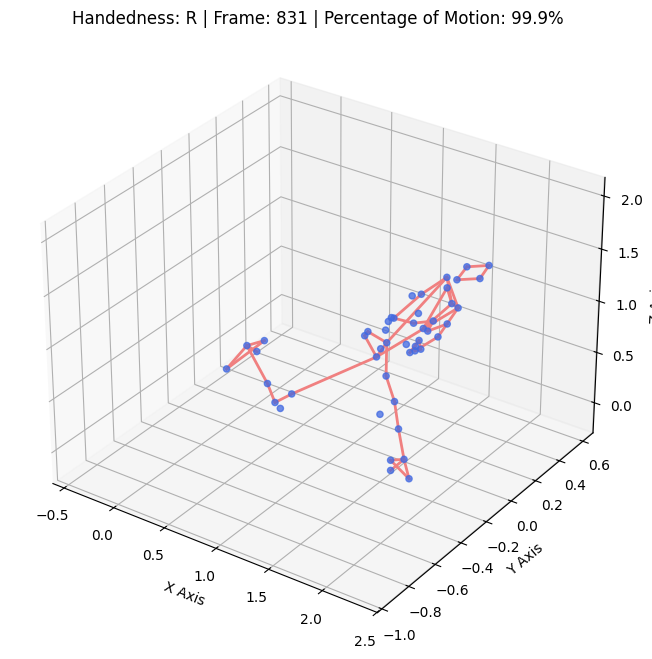

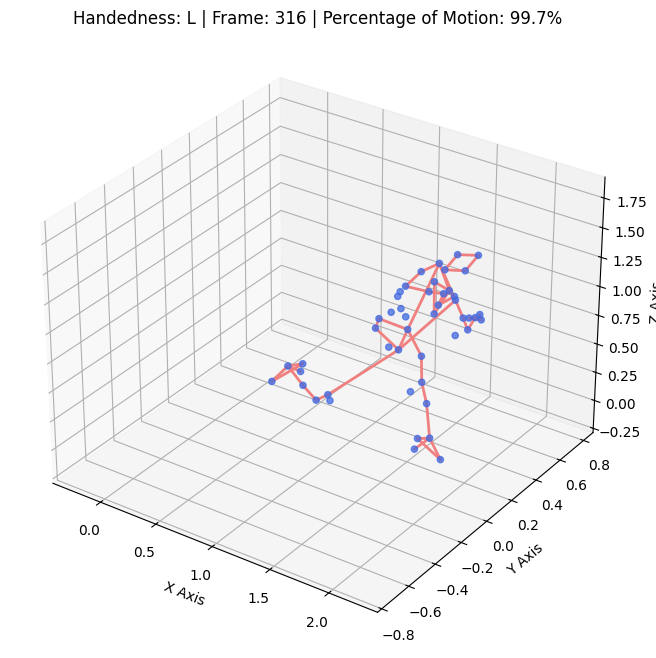

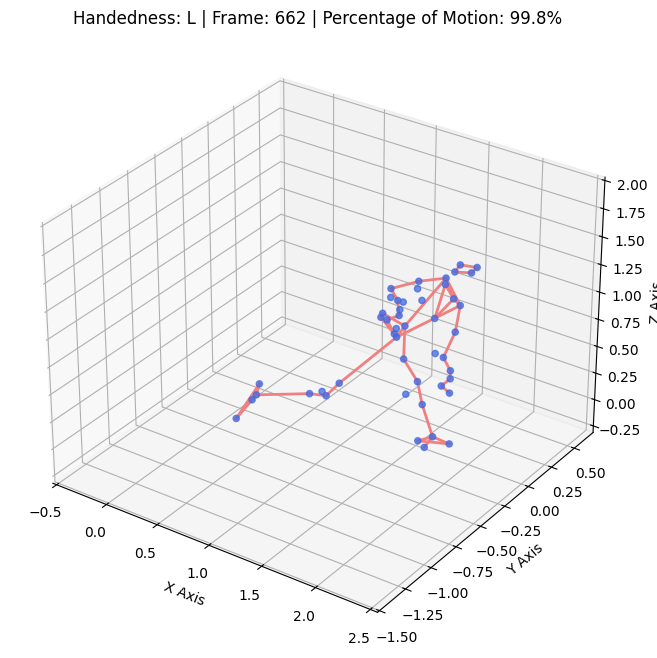

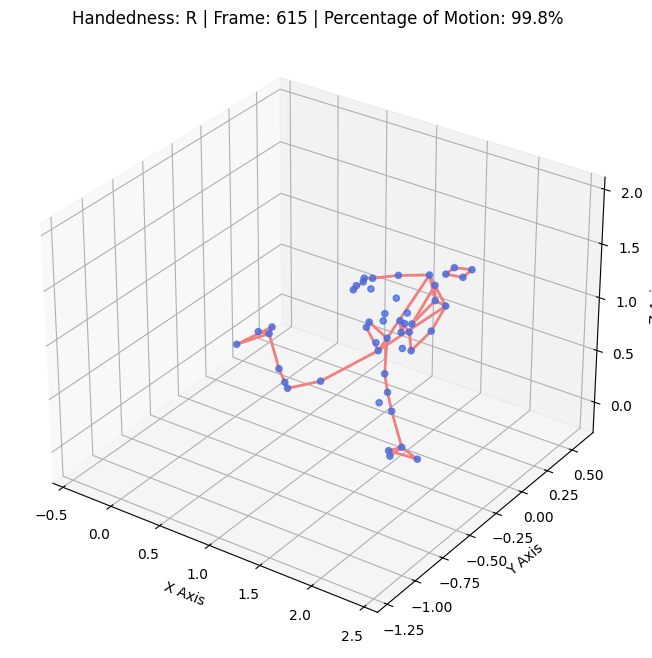

In [19]:
for i in range(len(pitch_of_interest)):
    print(f"Starting animation {i}")
    singleview(pitch_number = i)
print("Done Animating")

In [20]:
def multiview(pitch_number):
    with open("../data/pitch_marker_mapping.json", 'r') as f:
        pitch_marker_mapping = json.load(f)

    # Pitch selection
    # pitch_number = 0
    userID = pitch_of_interest[pitch_number][0]
    sessionID = pitch_of_interest[pitch_number][1]
    pitchNum = pitch_of_interest[pitch_number][2]

    sel = data[
        (data['userID'] == userID) &
        (data['sessionID'] == sessionID) &
        (data['pitchNum'] == pitchNum)
    ].copy()
    
    # Step 1: identify first frame
    first_frame = sel['frame'].min()

    # Step 2: compute first-frame mean Y (only valid markers)
    first_frame_mean_y = sel[sel['frame'] == first_frame]['y'].mean()

    # Step 3: subtract baseline from all frames
    sel['y'] = sel['y'] - first_frame_mean_y


    # --- Load C3D file for marker labels ---
    height = sel['height'].iloc[0]
    weight = sel['weight'].iloc[0]
    pitchType = sel['pitchType'].iloc[0]
    pitchSpeed = str(int(sel['pitchSpeed'].iloc[0]*10))  # convert back to C3D filename format
    hand = sel["p_throws"].iloc[0]


    pitch_key = f"{userID}_{sessionID}_{pitchNum}"
    marker_labels = pitch_marker_mapping[pitch_key]
    label_to_index = {label: i for i, label in enumerate(marker_labels)}
    def get_idx(label): return label_to_index.get(label)

    # --- Convert DataFrame to points array ---
    unique_markers = sorted(sel['markerID'].unique())
    unique_frames = sorted(sel['frame'].unique())
    num_markers = len(unique_markers)
    num_frames = len(unique_frames)

    marker_to_idx = {marker: i for i, marker in enumerate(unique_markers)}
    frame_to_idx = {frame: i for i, frame in enumerate(unique_frames)}

    points = np.full((3, num_markers, num_frames), np.nan)
    for _, row in sel.iterrows():
        m_idx = marker_to_idx[row['markerID']]
        f_idx = frame_to_idx[row['frame']]
        points[0, m_idx, f_idx] = row['x']
        points[1, m_idx, f_idx] = row['y']
        points[2, m_idx, f_idx] = row['z']

    # Define connections
    skeleton_connections_labels = [
        # Head and Neck
        (get_idx('LBHD'), get_idx('LFHD')), # Left Head
        (get_idx('RBHD'), get_idx('RFHD')), # Right Head
        (get_idx('LFHD'), get_idx('RFHD')), # Forehead
        (get_idx('LBHD'), get_idx('RBHD')), # Back of Head
        (get_idx('C7'), get_idx('STRN')),  # Neck to Sternum (approx. upper torso center)
        (get_idx('C7'), get_idx('CLAV')),  # C7 to Clavicle (upper spine to shoulder girdle)
        
        # Torso
        (get_idx('STRN'), get_idx('CLAV')), # Sternum to Clavicle
        (get_idx('CLAV'), get_idx('LSHO')), # Clavicle to Left Shoulder
        (get_idx('CLAV'), get_idx('RSHO')), # Clavicle to Right Shoulder
        (get_idx('LSHO'), get_idx('RSHO')), # Across shoulders
        (get_idx('LSHO'), get_idx('LASI')), # Left Shoulder to Left ASIS (approx. body side)
        (get_idx('RSHO'), get_idx('RASI')), # Right Shoulder to Right ASIS
        (get_idx('LASI'), get_idx('RASI')), # Across hips
        (get_idx('LPSI'), get_idx('RPSI')), # Across posterior hips (if available, good for pelvis)
        (get_idx('LASI'), get_idx('LPSI')), # Left ASIS to Left PSIS
        (get_idx('RASI'), get_idx('RPSI')), # Right ASIS to Right PSIS
        
        # Left Arm
        (get_idx('LSHO'), get_idx('LUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('LUPA'), get_idx('LELB')), # Upper Arm to Elbow
        (get_idx('LELB'), get_idx('LFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('LFRM'), get_idx('LWRA')), # Forearm to Wrist A
        (get_idx('LWRA'), get_idx('LWRB')), # Wrist A to Wrist B
        (get_idx('LWRB'), get_idx('LFIN')), # Wrist B to Finger
        
        # Right Arm
        (get_idx('RSHO'), get_idx('RUPA')), # Shoulder to Upper Arm (Bicep)
        (get_idx('RUPA'), get_idx('RELB')), # Upper Arm to Elbow
        (get_idx('RELB'), get_idx('RFRM')), # Elbow to Forearm (Radius/Ulna)
        (get_idx('RFRM'), get_idx('RWRA')), # Forearm to Wrist A
        (get_idx('RWRA'), get_idx('RWRB')), # Wrist A to Wrist B
        (get_idx('RWRB'), get_idx('RFIN')), # Wrist B to Finger

        # Left Leg
        (get_idx('LASI'), get_idx('LTHI')), # ASIS to Thigh (femur)
        (get_idx('LTHI'), get_idx('LKNE')), # Thigh to Knee
        (get_idx('LKNE'), get_idx('LTIB')), # Knee to Tibia
        (get_idx('LTIB'), get_idx('LANK')), # Tibia to Ankle
        (get_idx('LANK'), get_idx('LHEE')), # Ankle to Heel
        (get_idx('LANK'), get_idx('LTOE')), # Ankle to Toe
        (get_idx('LHEE'), get_idx('LTOE')), # Heel to Toe
        (get_idx('LANK'), get_idx('LMANK')), # Left Ankle to Medial Ankle (if LMANK is medial)
        
        # Right Leg
        (get_idx('RASI'), get_idx('RTHI')), # ASIS to Thigh (femur)
        (get_idx('RTHI'), get_idx('RKNE')), # Thigh to Knee
        (get_idx('RKNE'), get_idx('RTIB')), # Knee to Tibia
        (get_idx('RTIB'), get_idx('RANK')), # Tibia to Ankle
        (get_idx('RANK'), get_idx('RHEE')), # Ankle to Heel
        (get_idx('RANK'), get_idx('RTOE')), # Ankle to Toe
        (get_idx('RHEE'), get_idx('RTOE')), # Heel to Toe
        (get_idx('RANK'), get_idx('RMANK')) # Right Ankle to Medial Ankle (if RMANK is medial)
    ]
    skeleton_connections = [conn for conn in skeleton_connections_labels if all(c is not None for c in conn)]

    # --- Setup figure with multiple subplots (5 views) ---
    fig = plt.figure(figsize=(20, 12))
    view_angles = [
        (30, -55),     # original
        (0, 0),        # xz plane (flat)
        (0, 90),       # yz plane (flat)
        (0, 180),      # backside xz
        (0, 270)       # backside yz
    ]
    axes = []
    scatters = []
    lines_list = []

    # Axis limits
    x_min, x_max = np.nanmin(points[0]), np.nanmax(points[0])
    y_min, y_max = np.nanmin(points[1]), np.nanmax(points[1])
    z_min, z_max = np.nanmin(points[2]), np.nanmax(points[2])
    buffer = 0.1 * (max(x_max-x_min, y_max-y_min, z_max-z_min) or 1)

    for i, (elev, azim) in enumerate(view_angles):
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        ax.set_xlim([x_min-buffer, x_max+buffer])
        ax.set_ylim([y_min-buffer, y_max+buffer])
        ax.set_zlim([z_min-buffer, z_max+buffer])
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        ax.view_init(elev=elev, azim=azim)
        axes.append(ax)

        scatter = ax.scatter(points[0, :, 0], points[1, :, 0], points[2, :, 0], color='royalblue')
        scatters.append(scatter)

        # Lines for skeleton
        lines = []
        for p1_idx, p2_idx in skeleton_connections:
            x = points[0, [p1_idx, p2_idx], 0]
            y = points[1, [p1_idx, p2_idx], 0]
            z = points[2, [p1_idx, p2_idx], 0]
            line, = ax.plot(x, y, z, color='lightcoral', lw=2)
            lines.append(line)
        lines_list.append(lines)
        # ax.set_title(f'View {i+1}')

    view_names = ["Overview", "Front", "Side 1", "Side 2", "Back"]
    def update(frame):

        for ax_idx in range(len(axes)):
            scatters[ax_idx]._offsets3d = (points[0, :, frame], points[1, :, frame], points[2, :, frame])
            for i, (p1_idx, p2_idx) in enumerate(skeleton_connections):
                x = points[0, [p1_idx, p2_idx], frame]
                y = points[1, [p1_idx, p2_idx], frame]
                z = points[2, [p1_idx, p2_idx], frame]
                lines_list[ax_idx][i].set_data(x, y)
                lines_list[ax_idx][i].set_3d_properties(z)

            axes[ax_idx].set_title(f'Handedness {hand}, {view_names[ax_idx]}, Frame {frame}, Percentage of Motion: {(frame/num_frames) * 100:.1f}%')
        # Return all updated artists
        if frame % 50 == 0:
            print(f"On frame {frame} of animation")
        return scatters + [line for lines in lines_list for line in lines]

    ani = FuncAnimation(fig, update, frames=num_frames, interval=15, blit=False)
    ani.save(f'./animations/multiview/{userID}_{sessionID}_{pitchNum}_multiangle.mp4', writer='ffmpeg', fps=60)
    print(f"Animation saved as {userID}_{sessionID}_{pitchNum}_multiangle.mp4")

In [21]:
# multiview(0)